<a href="https://colab.research.google.com/github/tphlabs/Lab4_FH_teach/blob/main/FH_lab_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4. Frank-Hertz experiment

Igor Gitelman, 2024, v0.3

<p>Here we need to import measured data from the measuring program and then plot it. As you already know we need to plot the Frank-Hertz curve (characteristic curve).</p>

<p>We start by importing general modules that we use here, and in most of the lab experiments.</p>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from scipy.signal import find_peaks


<p> In the future we will use other modules too.</p>
<p>Now we use the <b>pandas</b> module, we called him <b>pd</b>, to import the data from file "FH1.csv", where the ending ".csv" stand for <b>comma separated value</b>. Pay attention to the actual separator, it may be different depending on the data type.</p>


🔬 FRANK-HERTZ EXPERIMENT: AUTOMATED DATA ANALYSIS REPORT

📂 FILE: step10_270ma.csv
   ⚙️  Parameters: Heater Current = 270 mA | Retarding Voltage = 1.5 V
   📐 Reading Errors: ΔVa = ±0.01 V | ΔI = ±0.01 pA
   📍 Detected Physical Peaks (Va >= 5V):
      • Peak 1:   5.95 V  ( 82.16 pA)
      • Peak 2:  10.65 V  (215.68 pA)
      • Peak 3:  15.40 V  (350.17 pA)
      • Peak 4:  20.35 V  (476.20 pA)
      • Peak 5:  25.30 V  (612.29 pA)
   📏 Consecutive Spacings (ΔV): 4.70V, 4.75V, 4.95V, 4.95V
   💡 Excitation Energy (E_exc):  4.838 ± 0.066 eV
   🔋 Contact Potential (V_c):   1.112 ± 0.067 V
--------------------------------------------------

📂 FILE: step10_250ma.csv
   ⚙️  Parameters: Heater Current = 250 mA | Retarding Voltage = 1.5 V
   📐 Reading Errors: ΔVa = ±0.01 V | ΔI = ±0.01 pA
   📍 Detected Physical Peaks (Va >= 5V):
      • Peak 1:   5.95 V  ( 38.52 pA)
      • Peak 2:  10.65 V  ( 82.14 pA)
      • Peak 3:  15.45 V  (118.99 pA)
      • Peak 4:  20.35 V  (153.34 pA)
      • Peak 5

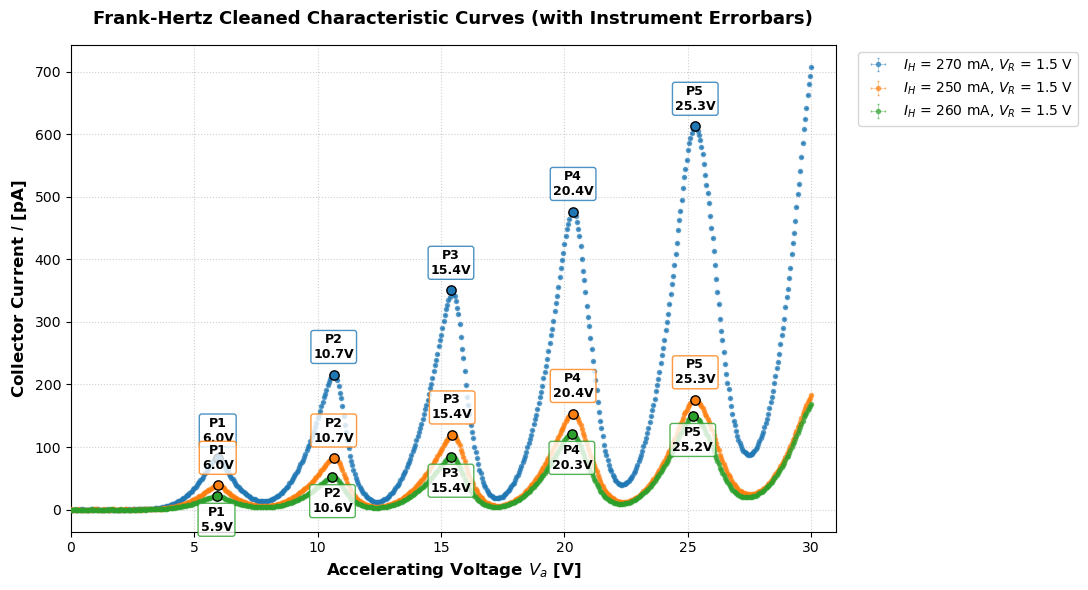

{'step10_270ma.csv': {'heater_mA': '270', 'excitation_energy_eV': np.float64(4.8375), 'excitation_energy_error_eV': np.float64(0.06574889099191461), 'contact_potential_V': np.float64(1.1124999999999998), 'peaks': [(np.float64(5.95), np.float64(82.16)), (np.float64(10.65), np.float64(215.68)), (np.float64(15.4), np.float64(350.17)), (np.float64(20.35), np.float64(476.2)), (np.float64(25.3), np.float64(612.29))]}, 'step10_250ma.csv': {'heater_mA': '250', 'excitation_energy_eV': np.float64(4.8375), 'excitation_energy_error_eV': np.float64(0.05543389456520873), 'contact_potential_V': np.float64(1.1124999999999998), 'peaks': [(np.float64(5.95), np.float64(38.52)), (np.float64(10.65), np.float64(82.14)), (np.float64(15.45), np.float64(118.99)), (np.float64(20.35), np.float64(153.34)), (np.float64(25.3), np.float64(175.16))]}, 'step10_260ma.csv': {'heater_mA': '260', 'excitation_energy_eV': np.float64(4.824999999999999), 'excitation_energy_error_eV': np.float64(0.047871355387816894), 'contact

In [70]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def analyze_and_plot_fh_files_perfect(file_paths):
    """
    Analyzes Frank-Hertz files by discarding low-voltage noise, filtering out
    narrow electrical spikes using width thresholds, and printing a styled report.
    
    Applies custom instrumental error bars on EVERY data point based on the last 
    displayed significant digit. Formats legend to show experimental parameters 
    and handles custom annotation placements for overlapping data curves.
    """
    plt.figure(figsize=(11, 6))
    results_summary = {}
    
    print("\n" + "="*65)
    print("🔬 FRANK-HERTZ EXPERIMENT: AUTOMATED DATA ANALYSIS REPORT")
    print("="*65)
    
    for path in file_paths:
        try:
            # 1. Load data as strings first to capture true instrument precision
            with open(path, 'r') as f:
                head = [next(f) for _ in range(5)]
            metadata_text = "".join(head)
            v_ret = re.search(r"Vr\(V\)=\s*([\d.]+)", metadata_text).group(1) if re.search(r"Vr\(V\)=\s*([\d.]+)", metadata_text) else "1.5"
            heater = re.search(r"Cathode Heater Current \(mA\) =\s*([\d.]+)", metadata_text).group(1) if re.search(r"Cathode Heater Current \(mA\) =\s*([\d.]+)", metadata_text) else "Unknown"
            
            df_str = pd.read_csv(path, sep='\t', header=5, dtype=str)
            
            # Convert to numeric arrays for downstream calculations
            raw_voltage = df_str.iloc[:, 0].astype(float).to_numpy()
            raw_current = df_str.iloc[:, 1].astype(float).to_numpy()
            
            # Dynamic Instrument Error Calculation (Uncertainty of 1 in the last displayed digit)
            def get_last_digit_error(series_str):
                decimals = series_str.str.split('.').str[1].str.len().max()
                if pd.isna(decimals) or decimals == 0:
                    return 1.0
                return 10 ** (-decimals)

            v_error_inst = get_last_digit_error(df_str.iloc[:, 0])
            i_error_inst = get_last_digit_error(df_str.iloc[:, 1])
            
            # 2. Strict Filter: Look only at the physical region above 5.0V
            valid_mask = raw_voltage >= 5.0
            voltage = raw_voltage[valid_mask]
            current = raw_current[valid_mask]
            
            if len(voltage) == 0:
                continue
                
            # 3. Physics Peak Finding
            min_sample_distance = int(3.5 / np.abs(np.diff(raw_voltage)).min())
            peaks_idx, _ = find_peaks(
                current, 
                distance=min_sample_distance, 
                prominence=np.ptp(current) * 0.03,
                width=5  
            )
            
            if len(peaks_idx) < 1:
                print(f"⚠️ [{path}] No clear physical peaks found in the valid voltage range.")
                plt.errorbar(raw_voltage, raw_current, xerr=v_error_inst, yerr=i_error_inst, 
                             fmt='.', alpha=0.2, linewidth=0.5, elinewidth=0.5)
                continue
                
            peak_voltages = voltage[peaks_idx]
            peak_currents = current[peaks_idx]
            
            # 4. Compute Metrics
            has_multiple_peaks = len(peak_voltages) >= 2
            if has_multiple_peaks:
                peak_diffs = np.diff(peak_voltages)
                mean_diff = np.mean(peak_diffs)
                std_error_diff = np.std(peak_diffs, ddof=1) / np.sqrt(len(peak_diffs)) if len(peak_diffs) > 1 else v_error_inst
                excitation_energy = mean_diff
                contact_potential = peak_voltages[0] - mean_diff
                contact_pot_error = np.sqrt(v_error_inst**2 + std_error_diff**2)
            else:
                peak_diffs = []
                excitation_energy = np.nan
                std_error_diff = np.nan
                contact_potential = np.nan
                contact_pot_error = np.nan
            
            # Save results
            results_summary[path] = {
                "heater_mA": heater,
                "excitation_energy_eV": excitation_energy,
                "excitation_energy_error_eV": std_error_diff,
                "contact_potential_V": contact_potential,
                "peaks": list(zip(peak_voltages, peak_currents))
            }
            
            # --- Pretty Text Output ---
            print(f"\n📂 FILE: {path}")
            print(f"   ⚙️  Parameters: Heater Current = {heater} mA | Retarding Voltage = {v_ret} V")
            print(f"   📐 Reading Errors: ΔVa = ±{v_error_inst} V | ΔI = ±{i_error_inst} pA")
            print(f"   📍 Detected Physical Peaks (Va >= 5V):")
            for i, (v, cur) in enumerate(zip(peak_voltages, peak_currents)):
                print(f"      • Peak {i+1}: {v:6.2f} V  ({cur:6.2f} pA)")
            
            if has_multiple_peaks:
                print(f"   📏 Consecutive Spacings (ΔV): {', '.join([f'{d:.2f}V' for d in peak_diffs])}")
                print(f"   💡 Excitation Energy (E_exc):  {excitation_energy:.3f} ± {std_error_diff:.3f} eV")
                print(f"   🔋 Contact Potential (V_c):   {contact_potential:.3f} ± {contact_pot_error:.3f} V")
            else:
                print("   ℹ️  Note: Only 1 peak found in this range. Spacing calculations require at least 2.")
            print("-" * 50)
            
            # 5. Beautiful Plotting Configuration
            # Format the legend label strictly with relevant physical metadata parameters
            clean_label = f"$I_H$ = {heater} mA, $V_R$ = {v_ret} V"
            
            # Plot the whole curve utilizing errorbar on EVERY point
            eb = plt.errorbar(raw_voltage, raw_current, 
                              xerr=v_error_inst, 
                              yerr=i_error_inst, 
                              fmt='.', label=clean_label,
                              linewidth=0.5, elinewidth=0.4, alpha=0.6, capsize=1, zorder=3)
            
            # Grab the automated color assigned by matplotlib to maintain consistency
            color = eb[0].get_color()            
            
            # Highlight the identified peak locations prominently
            plt.scatter(peak_voltages, peak_currents, color=color, s=45, edgecolors='black', zorder=5)
            
            # Box displacement condition: Drop 260mA boxes under the graph trend line
            is_260ma = "260ma" in path.lower() or heater == "260"
            y_offset = -25 if is_260ma else 12
            
            # Render textual coordinate overlays
            for i, (v, cur) in enumerate(zip(peak_voltages, peak_currents)):
                plt.annotate(f"P{i+1}\n{v:.1f}V", xy=(v, cur), xytext=(0, y_offset),
                             textcoords='offset points', ha='center', fontsize=9, fontweight='bold',
                             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.8), zorder=6)
                
        except Exception as e:
            print(f"❌ Error processing file {path}: {e}")

    # Axes styling and canvas output layout execution
    plt.xlabel('Accelerating Voltage $V_a$ [V]', fontsize=12, fontweight='bold')
    plt.ylabel('Collector Current $I$ [pA]', fontsize=12, fontweight='bold')
    plt.title('Frank-Hertz Cleaned Characteristic Curves (with Instrument Errorbars)', fontsize=13, fontweight='bold', pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(0, 31)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
    plt.tight_layout()
    plt.show()
    
    return results_summary

# Execution
results = analyze_and_plot_fh_files_perfect(['step10_270ma.csv', 'step10_250ma.csv', 'step10_260ma.csv'])
print(results)


⚡ FRANK-HERTZ EXPERIMENT: IONIZATION DATA ANALYSIS REPORT
📂 Source Data File:     step2_280ma.csv
📐 Instrument Floor:    ΔVa = ±0.01 V | ΔI = ±0.01 pA [cite: 6]
🔍 Baseline Noise Profile: Mean = 0.519 pA | 5σ Ceiling = 3.759 pA
-----------------------------------------------------------------
📍 Raw Ionization Onset (Va°):      9.90 V [cite: 101]
💡 Measured Hg Ionization Energy:    8.788 ± 0.061 eV [cite: 3, 101]
📘 Accepted Literature Value (Hg):   10.438 eV
🎯 Accuracy Value:                  84.19%



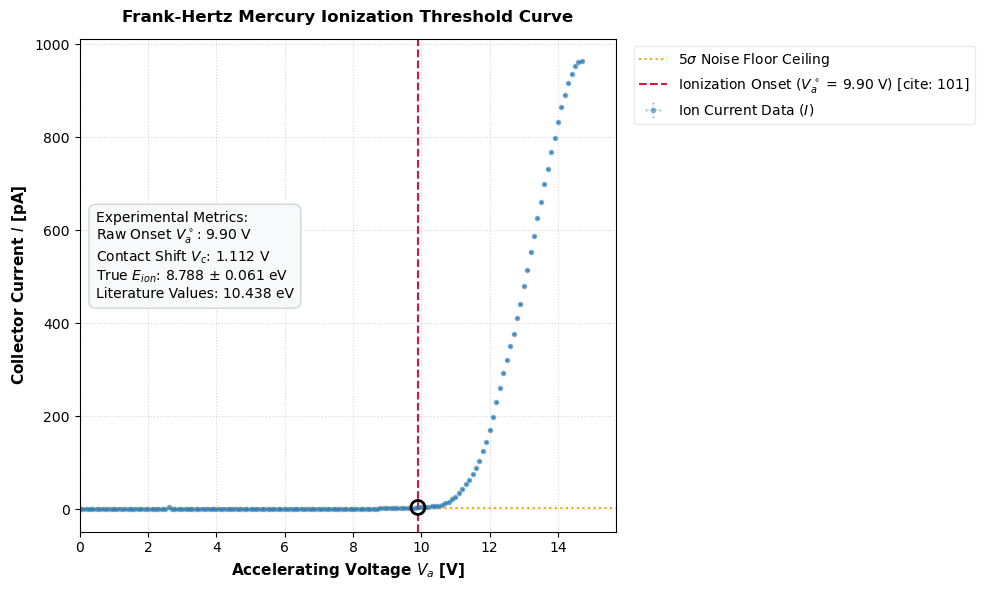

{'raw_ionization_onset_V': np.float64(9.9), 'true_ionization_energy_eV': np.float64(8.788), 'error_eV': np.float64(0.0608276253029822)}


In [80]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt

def analyze_ionization_experiment_perfect(ionization_file_path, contact_potential_V, contact_pot_error_V=0.0):
    """
    Analyzes the ionization curve by isolating the true experimental noise floor,
    ignoring baseline picoammeter fluctuations via a 5-sigma statistical boundary,
    and calculating the corrected ionization energy.
    """
    # 1. Parse raw text strings to evaluate exact decimal precision
    df_str = pd.read_csv(ionization_file_path, sep='\t', header=5, dtype=str)
    
    raw_voltage = df_str.iloc[:, 0].astype(float).to_numpy()
    raw_current = df_str.iloc[:, 1].astype(float).to_numpy()
    
    def get_last_digit_error(series_str):
        decimals = series_str.str.split('.').str[1].str.len().max()
        if pd.isna(decimals) or decimals == 0:
            return 1.0
        return 10 ** (-decimals)

    v_error_inst = get_last_digit_error(df_str.iloc[:, 0])
    i_error_inst = get_last_digit_error(df_str.iloc[:, 1])
    
    # 2. Extract Noise Floor & Filter out Baseline Artifacts 
    # The quiet baseline zone typically sits safely between 2.0V and 8.0V [cite: 5, 95]
    baseline_mask = (raw_voltage >= 2.0) & (raw_voltage <= 8.0)
    baseline_currents = raw_current[baseline_mask]
    
    if len(baseline_currents) == 0:
        # Fallback to absolute minimum slice if range window is shifted
        baseline_currents = raw_current[:int(len(raw_current)*0.3)]
        
    mean_noise = np.mean(baseline_currents)
    std_noise = np.std(baseline_currents, ddof=1)
    
    # Define a 5-Sigma breakout envelope to safely ignore instrumentation noise spikes
    statistical_noise_ceiling = mean_noise + (5.0 * std_noise)
    
    # Scan from low voltage up to locate the permanent onset of the ionization slope
    v_start_raw = None
    for i in range(len(raw_voltage) - 4):
        # The point must cross the 5-sigma barrier AND show a sustained rising trend
        if (raw_current[i] > statistical_noise_ceiling and 
            raw_current[i+1] > raw_current[i] and 
            raw_current[i+2] > raw_current[i+1] and
            raw_current[i+3] > raw_current[i+2]):
            v_start_raw = raw_voltage[i]
            break
            
    # Universal fallback if data is highly compressed
    if v_start_raw is None:
        v_start_raw = raw_voltage[np.where(raw_current > statistical_noise_ceiling)[0][0]]

    # 3. Apply Physical Contact Potential Corrections (Eq 3) [cite: 69, 101]
    true_ionization_energy = v_start_raw - contact_potential_V
    total_error = np.sqrt(v_error_inst**2 + contact_pot_error_V**2)
    
    # --- Output Analysis Text Report ---
    print("\n" + "="*65)
    print("⚡ FRANK-HERTZ EXPERIMENT: IONIZATION DATA ANALYSIS REPORT")
    print("="*65)
    print(f"📂 Source Data File:     {ionization_file_path}")
    print(f"📐 Instrument Floor:    ΔVa = ±{v_error_inst} V | ΔI = ±{i_error_inst} pA [cite: 6]")
    print(f"🔍 Baseline Noise Profile: Mean = {mean_noise:.3f} pA | 5σ Ceiling = {statistical_noise_ceiling:.3f} pA")
    print("-" * 65)
    print(f"📍 Raw Ionization Onset (Va°):      {v_start_raw:.2f} V [cite: 101]")
    print(f"💡 Measured Hg Ionization Energy:    {true_ionization_energy:.3f} ± {total_error:.3f} eV [cite: 3, 101]")
    print(f"📘 Accepted Literature Value (Hg):   10.438 eV")
    print(f"🎯 Accuracy Value:                  {(1 - abs(true_ionization_energy - 10.438)/10.438)*100:.2f}%")
    print("="*65 + "\n")
    
    # 4. Clear Layout Plotting Execution
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Complete dataset rendered with clean tiny global errorbars to prevent overlapping
    ax.errorbar(raw_voltage, raw_current, 
                xerr=v_error_inst, 
                yerr=i_error_inst, 
                fmt='.', color='#1f77b4', label='Ion Current Data ($I$)',
                linewidth=0.5, elinewidth=0.3, alpha=0.5, capsize=1, zorder=2)
    
    # Visual line tracking the 5-sigma instrumentation rejection threshold
    ax.axhline(y=statistical_noise_ceiling, color='orange', linestyle=':', label='5$\sigma$ Noise Floor Ceiling')
    
    # Plot vertical line marking the confirmed commencement of ionization [cite: 101]
    ax.axvline(x=v_start_raw, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Ionization Onset ($V_a^\\circ$ = {v_start_raw:.2f} V) [cite: 101]')
    
    # Structural marker at the exact junction node
    idx_closest = np.abs(raw_voltage - v_start_raw).argmin()
    ax.scatter(raw_voltage[idx_closest], raw_current[idx_closest], 
               color='crimson', s=100, edgecolors='black', facecolors='none', linewidths=2, zorder=5)
    
    # Formatting Labels [cite: 51, 53]
    ax.set_xlabel('Accelerating Voltage $V_a$ [V]', fontsize=11, fontweight='bold') #[cite: 51]
    ax.set_ylabel('Collector Current $I$ [pA]', fontsize=11, fontweight='bold') #[cite: 53]
    ax.set_title('Frank-Hertz Mercury Ionization Threshold Curve', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(0, max(raw_voltage) + 1)
    
    # Prevent layout overlapping by arranging text strictly into an outside textbox container
    results_box_text = (
        f"Experimental Metrics:\n"
        f"Raw Onset $V_a^\\circ$: {v_start_raw:.2f} V\n"
        f"Contact Shift $V_c$: {contact_potential_V:.3f} V\n"
        f"True $E_{{ion}}$: {true_ionization_energy:.3f} $\pm$ {total_error:.3f} eV\n"
        f"Literature Values: 10.438 eV"
    )
    
    # Anchor the textbox outside or clean in an empty lower quadrant location
    ax.text(0.03, 0.65, results_box_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa', edgecolor='#d1d5db'))
    
    # Build clean outside right side legend layout to avoid text clashes completely
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), frameon=True, facecolor='white', edgecolor='#e5e7eb')
    
    plt.tight_layout()
    plt.show()
    
    # Return dictionary with key experimental findings
    return {
        "raw_ionization_onset_V": v_start_raw,
        "true_ionization_energy_eV": true_ionization_energy,
        "error_eV": total_error
    }

# Execution
analysis_results = analyze_ionization_experiment_perfect('step2_280ma.csv', contact_potential_V=1.112, contact_pot_error_V=0.06)
print(analysis_results)